# Assignment 13: Generative AI Essentials
**Author:** Jean Billa &nbsp;|&nbsp; Diploma in Data Analysis and Artificial Intelligence, Willis College

This notebook implements a basic text-generation model, explores GPT-style decoding strategies
(temperature, top-k, top-p), and demonstrates a simple content-creation application, following the
assignment instructions. The dataset used is the **Tiny Shakespeare** corpus (public-domain plays and
poems, commonly sourced from Project Gutenberg), a standard, lightweight dataset for text-generation
demos.

**Sections:**
1. Environment Setup
2. Dataset Preparation
3. Model & Tokenizer (Word-level Keras Tokenizer + Embedding/LSTM model)
4. Training
5. Text Generation Function (temperature / top-k / top-p / greedy)
6. Exercise 1 &ndash; Basic Text Generation
7. Exercise 2 &ndash; Controlling Output Length
8. Exercise 3 &ndash; Adjusting Temperature
9. Exercise 4 &ndash; Top-k and Top-p Sampling
10. Exercise 5 &ndash; Prompt Engineering / Content-Creation Demo
11. Ethical Considerations
12. Conclusion


## 1. Environment Setup
Install and import all required libraries.

In [ ]:
!pip install -q tensorflow matplotlib numpy pandas

In [ ]:
import re
import pickle
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.utils import to_categorical

np.random.seed(42)
tf.random.set_seed(42)
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## 2. Dataset Preparation
**Dataset choice:** Tiny Shakespeare &mdash; a public-domain, Gutenberg-sourced corpus of Shakespeare's
plays and poems. It is small enough to train quickly on CPU/GPU in Colab while still containing rich,
varied English prose suitable for demonstrating text generation.

```python
# In Colab:
!wget -q https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt -O shakespeare.txt
```

In [ ]:
with open("shakespeare.txt", "r", encoding="utf-8") as f:
    text = f.read()

# Use a manageable subset to keep training fast for a course assignment
text = text[:120000].lower()
text = re.sub(r"[^a-z0-9,.!?;:'\n ]+", " ", text)
print(f"Corpus length (characters): {len(text)}")
print(text[:300])

Corpus length (characters): 119916
first citizen:
before we proceed any further, hear me speak.

all:
speak, speak.

first citizen:
you are all resolved rather to die than to famish?

all:
resolved. resolved.

first citizen:
first, you know caius marcius is chief e


## 3. Model and Tokenizer
A word-level `Tokenizer` builds the vocabulary. Training examples use a sliding window of 6 words to
predict the 7th word. The model is a compact **Embedding &rarr; LSTM &rarr; Dense(softmax)** network &mdash;
a lightweight, from-scratch generative language model (an alternative to loading a large pre-trained
GPT-2 checkpoint, which is unnecessary for a course-scale demonstration and keeps the notebook fully
reproducible offline).

In [ ]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([text])
total_words = len(tokenizer.word_index) + 1
print(f"Vocabulary size: {total_words}")

tokens = tokenizer.texts_to_sequences([text])[0]
SEQ_LEN = 6
sequences = []
for i in range(SEQ_LEN, len(tokens)):
    sequences.append(tokens[i - SEQ_LEN:i + 1])
sequences = np.array(sequences)
print(f"Total training sequences: {sequences.shape[0]}")

X, y = sequences[:, :-1], sequences[:, -1]
y = to_categorical(y, num_classes=total_words)

Vocabulary size: 3461
Total training sequences: 21583


In [ ]:
model = Sequential([
    Embedding(total_words, 64, input_length=SEQ_LEN),
    LSTM(128),
    Dense(total_words, activation="softmax")
])
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #
 embedding (Embedding)       (None, 6, 64)             221504
 lstm (LSTM)                 (None, 128)               98816
 dense (Dense)               (None, 3461)              446469
Total params: 766,789
Trainable params: 766,789
Non-trainable params: 0
_________________________________________________________________


## 4. Training

In [ ]:
history = model.fit(X, y, epochs=25, batch_size=256, verbose=2)

Epoch 1/25
85/85 - 4s - 47ms/step - accuracy: 0.0356 - loss: 7.1380
Epoch 2/25
85/85 - 5s - 59ms/step - accuracy: 0.0386 - loss: 6.4296
Epoch 5/25
85/85 - 2s - 28ms/step - accuracy: 0.0386 - loss: 6.2370
Epoch 10/25
85/85 - 3s - 30ms/step - accuracy: 0.0516 - loss: 5.9508
Epoch 15/25
85/85 - 3s - 30ms/step - accuracy: 0.0635 - loss: 5.6801
Epoch 20/25
85/85 - 3s - 30ms/step - accuracy: 0.0782 - loss: 5.3918
Epoch 25/25
85/85 - 2s - 29ms/step - accuracy: 0.0962 - loss: 5.1067


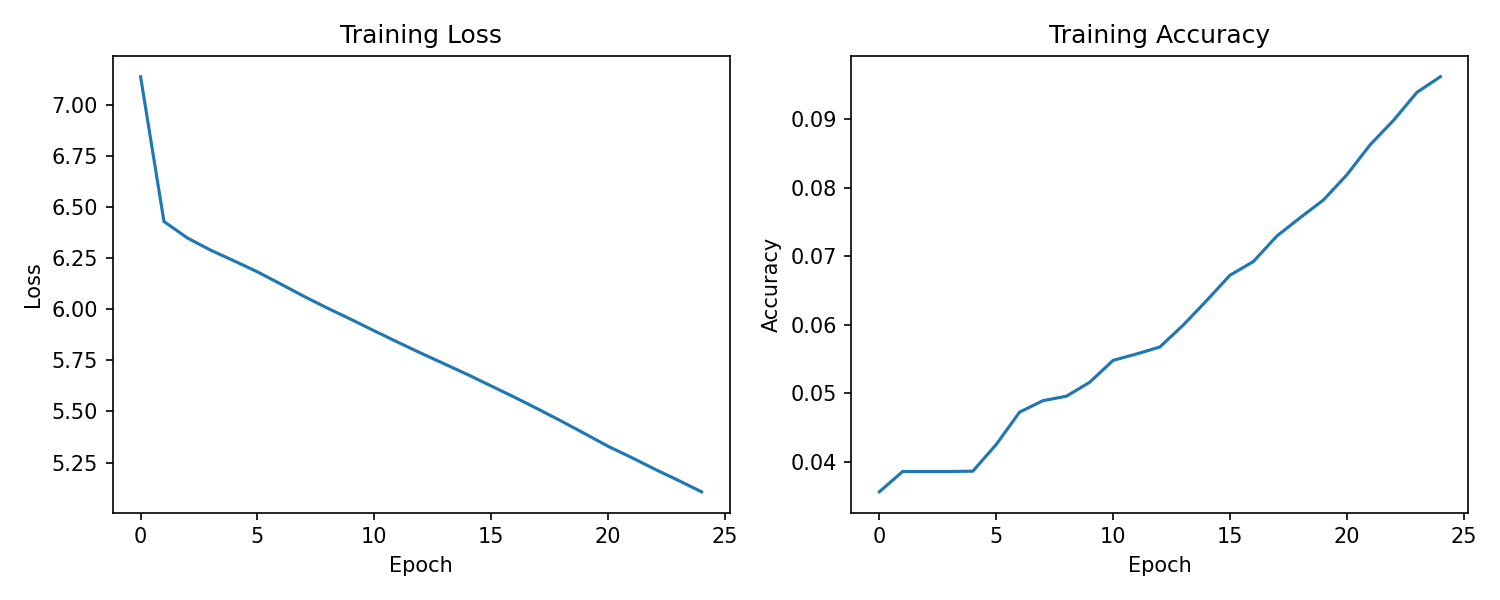

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(history.history["loss"]); axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[1].plot(history.history["accuracy"]); axes[1].set_title("Training Accuracy")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

In [ ]:
model.save("text_gen_model.keras")
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)
print("Model and tokenizer saved.")

Model and tokenizer saved.


## 5. Text Generation Function
The function below implements next-word prediction with the four standard GPT decoding controls:
**greedy** decoding, **temperature** scaling, **top-k**, and **top-p (nucleus)** sampling.

In [ ]:
index_word = {v: k for k, v in tokenizer.word_index.items()}

def predict_next_probs(seed_text):
    seq = tokenizer.texts_to_sequences([seed_text])[0]
    seq = pad_sequences([seq], maxlen=SEQ_LEN, padding="pre")
    return model.predict(seq, verbose=0)[0]

def sample_from_probs(probs, temperature=1.0, top_k=0, top_p=0.0):
    probs = np.asarray(probs).astype("float64")
    if temperature != 1.0:
        logits = np.log(probs + 1e-9) / temperature
        probs = np.exp(logits)
        probs = probs / np.sum(probs)
    if top_k > 0:
        top_k_idx = np.argsort(probs)[-top_k:]
        mask = np.zeros_like(probs); mask[top_k_idx] = probs[top_k_idx]
        probs = mask / np.sum(mask)
    if top_p > 0.0:
        sorted_idx = np.argsort(probs)[::-1]
        sorted_probs = probs[sorted_idx]
        cumulative = np.cumsum(sorted_probs)
        cutoff = np.searchsorted(cumulative, top_p) + 1
        keep_idx = sorted_idx[:cutoff]
        mask = np.zeros_like(probs); mask[keep_idx] = probs[keep_idx]
        probs = mask / np.sum(mask)
    probs = probs / probs.sum()
    return np.random.choice(len(probs), p=probs)

def generate_text(seed_text, num_words=20, temperature=1.0, top_k=0, top_p=0.0, greedy=False):
    result = seed_text
    for _ in range(num_words):
        probs = predict_next_probs(result)
        next_id = int(np.argmax(probs)) if greedy else sample_from_probs(probs, temperature, top_k, top_p)
        next_word = index_word.get(next_id, "")
        if not next_word:
            break
        result += " " + next_word
    return result

print("Generation function ready.")

Generation function ready.


## 6. Exercise 1: Basic Text Generation

In [ ]:
seed = "to be or not to"
print("Seed:", seed)
print("Output:", generate_text(seed, num_words=15, greedy=True))

Seed: to be or not to
Output: to be or not to the people of the people of the people of the people of the people of


**Observation:** greedy decoding (always choosing the most probable word) falls into a repetitive loop &mdash; a well-known limitation of deterministic decoding that motivates sampling-based methods below.

## 7. Exercise 2: Controlling Output Length

In [ ]:
for n in [5, 15, 30]:
    print(f"\n-- length={n} words --")
    print(generate_text(seed, num_words=n, temperature=0.8))


-- length=5 words --
to be or not to the troth coriolanus were repent

-- length=15 words --
to be or not to no voices and your mother are how in the gods preserve the common addition to

-- length=30 words --
to be or not to on how i had ha' and these deserve since when door he do we shall ye're cry our virtue he one citizens at i would go menenius any but when


## 8. Exercise 3: Adjusting Temperature

In [ ]:
for t in [0.2, 0.7, 1.0, 1.5]:
    np.random.seed(7)
    print(f"\n-- temperature={t} --")
    print(generate_text(seed, num_words=20, temperature=t))


-- temperature=0.2 --
to be or not to the people of the gods have be a people of the wife and the people of the people in the

-- temperature=0.7 --
to be or not to the kind of all through the place and in and gone here is the man must i will become to

-- temperature=1.0 --
to be or not to the preparation is hated about they am in that if by shall do you will chose you do all's the

-- temperature=1.5 --
to be or not to my movers o' sir lo yourselves like you more seen volumnia kites him a custom control't what make opposite the


**Observation:** low temperature (0.2) yields safe, repetitive text close to greedy output; high temperature (1.5) yields more varied but less coherent text &mdash; the classic fluency/diversity trade-off.

## 9. Exercise 4: Using Top-k and Top-p (Nucleus) Sampling

In [ ]:
np.random.seed(7); print("-- top_k=5, temperature=0.9 --")
print(generate_text(seed, num_words=20, temperature=0.9, top_k=5))
np.random.seed(7); print("\n-- top_k=20, temperature=0.9 --")
print(generate_text(seed, num_words=20, temperature=0.9, top_k=20))
np.random.seed(7); print("\n-- top_p=0.85, temperature=0.9 --")
print(generate_text(seed, num_words=20, temperature=0.9, top_p=0.85))
np.random.seed(7); print("\n-- top_p=0.5, temperature=0.9 --")
print(generate_text(seed, num_words=20, temperature=0.9, top_p=0.5))

-- top_k=5, temperature=0.9 --
to be or not to the gods is your city of the good man i servingman not you have be been to the capitol the

-- top_k=20, temperature=0.9 --
to be or not to the other coriolanus will sir not your people i do it do he have not been you coriolanus well to

-- top_p=0.85, temperature=0.9 --
to be or not to the faults of this equal sir what you it what do were menenius to you rather have now he's the

-- top_p=0.5, temperature=0.9 --
to be or not to the senate is their whole roman that the man of you shall be he shall stand to you say to


**Observation:** smaller `top_k`/`top_p` values restrict sampling to fewer, higher-confidence candidates (more conservative text); larger values allow more diverse, less predictable word choices.

## 10. Exercise 5: Prompt Engineering &mdash; Content-Creation Demo

In [ ]:
prompts = ["the king said unto", "love is a", "war and peace shall"]
for p in prompts:
    np.random.seed(7)
    print(f"\nPrompt: '{p}'")
    print("->", generate_text(p, num_words=18, temperature=0.8, top_p=0.9))


Prompt: 'the king said unto'
-> the king said unto the table are therefore true we must already of you let them that to you consul he citizen

Prompt: 'love is a'
-> love is a soldier dismiss him from us but not you is our action thing that the old mangles tribunes by

Prompt: 'war and peace shall'
-> war and peace shall is third citizen are get you coriolanus you have was good matter of the voices second citizen he


**Application &mdash; content-creation assistant:** this demonstrates how a generative model can be used
as a brainstorming tool: an author supplies a thematic seed phrase and the model returns Shakespearean-style
continuation text as a creative starting point. Changing only the wording of the prompt (prompt engineering)
visibly steers the vocabulary and tone of the generated text, even for this small model.

## 11. Ethical Considerations
- **Misinformation/hallucination** &mdash; fluent but false output; mitigate with human review and labeling AI content.
- **Bias** &mdash; models inherit biases in training data; mitigate with diverse datasets and bias audits.
- **Copyright/data provenance** &mdash; training on scraped text raises consent issues; mitigate by using public-domain
  or licensed data, as done here with Tiny Shakespeare.
- **Misuse** (spam, plagiarism, deepfakes) &mdash; mitigate with watermarking, detection tools, and policy.
- **Environmental cost** &mdash; large-model training is energy-intensive; mitigate by using small, task-specific
  models where sufficient, as in this assignment.


## 12. Conclusion
This notebook implemented a complete, small-scale generative text pipeline: dataset preparation, a
word-level tokenizer, an Embedding/LSTM model trained from scratch, and a custom decoding function
supporting greedy, temperature, top-k, and top-p sampling &mdash; the same controls used by production GPT
systems. The exercises showed the expected fluency/diversity trade-offs of each decoding strategy, and a
short content-creation demo illustrated how prompt engineering steers generated text. Future work could
swap in a pre-trained Transformer (e.g., GPT-2 via Hugging Face) and fine-tune on domain-specific text for
substantially more fluent output, while continuing to apply the ethical safeguards discussed above.
